In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import Dropout, Input, Add, Dense, Activation, BatchNormalization, Flatten, Conv2D, MaxPooling2D, GlobalMaxPooling2D
from tensorflow.keras.models import Model, load_model
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [34]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Krishna Desaboina\.cache\kagglehub\datasets\jangedoo\utkface-new\versions\1


In [35]:
from pathlib import Path
path = Path("C:/Users/Krishna Desaboina/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/utkface_aligned_cropped/crop_part1")
filenames = list(map(lambda x: x.name, path.glob('*.jpg')))
filenames[0:5]

['100_1_0_20170110183726390.jpg.chip.jpg',
 '100_1_2_20170105174847679.jpg.chip.jpg',
 '101_1_2_20170105174739309.jpg.chip.jpg',
 '10_0_0_20161220222308131.jpg.chip.jpg',
 '10_0_0_20170103200329407.jpg.chip.jpg']

In [36]:
np.random.seed(42)
np.random.shuffle(filenames)
age_labels, gender_labels, image_path = [], [], []
for filename in filenames:
    image_path.append(filename)
    temp = filename.split('_')
    age_labels.append(temp[0])
    gender_labels.append(temp[1])

In [37]:
data = pd.DataFrame()
data['image'], data['age'], data['gender'] = image_path, age_labels, gender_labels
data.dtypes

image     str
age       str
gender    str
dtype: object

In [38]:
gender_dict = {0:"Male",1:"Female"}
data = data.astype({'age':'float32', 'gender': 'int32'})
data.head()

,image,age,gender
0,1_0_2_20161219140811232.jpg.chip.jpg,1.0,0
1,5_1_4_20161219185942044.jpg.chip.jpg,5.0,1
2,2_0_3_20161219230614992.jpg.chip.jpg,2.0,0
3,62_0_0_20170111205902585.jpg.chip.jpg,62.0,0
4,10_1_0_20170109203501969.jpg.chip.jpg,10.0,1


In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 9780 entries, 0 to 9779
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   9780 non-null   str    
 1   age     9780 non-null   float32
 2   gender  9780 non-null   int32  
dtypes: float32(1), int32(1), str(1)
memory usage: 503.4 KB


In [40]:
data.describe()

,age,gender
count,9780.000000,9780.000000
mean,29.421576,0.553170
std,24.777334,0.497807
min,1.000000,0.000000
25%,7.000000,0.000000
50%,25.000000,1.000000
75%,49.000000,1.000000
max,110.000000,3.000000


The Gender for one image is wrongly entered as 3 instead of 1 or 0.

gender_dict = {0:"Male",1:"Female"}

In [41]:
data[data['gender']==3]

,image,age,gender
3603,61_3_20170109150557335.jpg.chip.jpg,61.0,3


My seeing photo it was interpreted as Female. 1 instead of 3.

In [42]:
data.loc[data['gender']==3, 'gender'] = 1

<Axes: title={'center': 'Gender Distribution'}, xlabel='gender'>

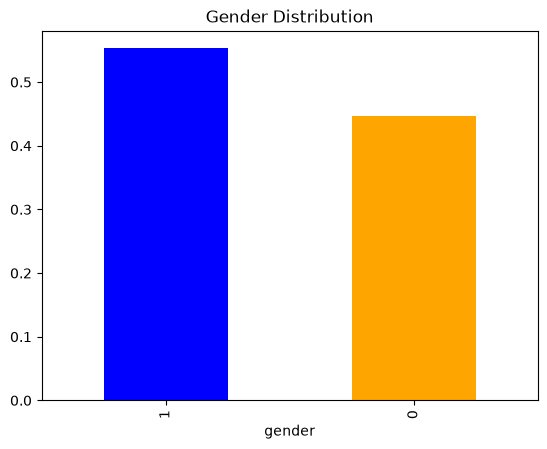

In [43]:
data['gender'].value_counts(normalize=True).plot(kind='bar', title='Gender Distribution', color=['blue', 'orange'])

[Text(0.5, 1.0, 'Distribution of Age')]

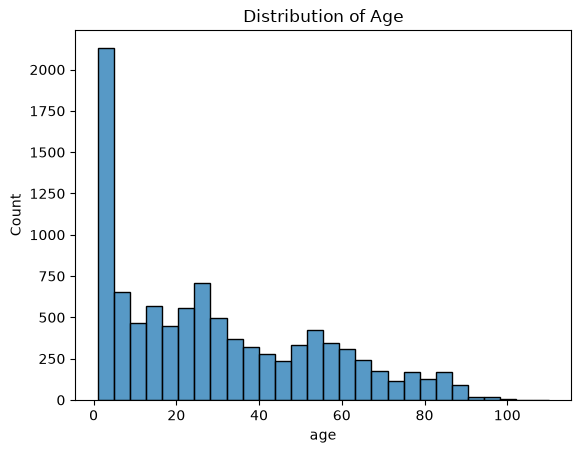

In [44]:
sns.histplot(data.age).set(title="Distribution of Age")

The Target users are mostly between 20 and 40. So, Using new data.

In [45]:
from pathlib import Path
path = Path("C:/Users/Krishna Desaboina/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/utkface_aligned_cropped/UTKFace")
filenames = list(map(lambda x: x.name, path.glob('*.jpg')))
filenames[0:5]

['100_0_0_20170112213500903.jpg.chip.jpg',
 '100_0_0_20170112215240346.jpg.chip.jpg',
 '100_1_0_20170110183726390.jpg.chip.jpg',
 '100_1_0_20170112213001988.jpg.chip.jpg',
 '100_1_0_20170112213303693.jpg.chip.jpg']

In [46]:
np.random.seed(42)
np.random.shuffle(filenames)
age_labels, gender_labels, image_path = [], [], []
for filename in filenames:
    image_path.append(filename)
    temp = filename.split('_')
    age_labels.append(temp[0])
    gender_labels.append(temp[1])

In [47]:
data = pd.DataFrame()
data['image'], data['age'], data['gender'] = image_path, age_labels, gender_labels
data.dtypes

image     str
age       str
gender    str
dtype: object

In [48]:
data = data.astype({'age':'float32', 'gender': 'int32'})
data.head()

,image,age,gender
0,49_1_0_20170104185652921.jpg.chip.jpg,49.0,1
1,17_1_0_20170109214200825.jpg.chip.jpg,17.0,1
2,17_1_4_20170103201233799.jpg.chip.jpg,17.0,1
3,29_0_4_20170103235921692.jpg.chip.jpg,29.0,0
4,26_1_2_20170116180208093.jpg.chip.jpg,26.0,1


[Text(0.5, 1.0, 'Distribution of Age')]

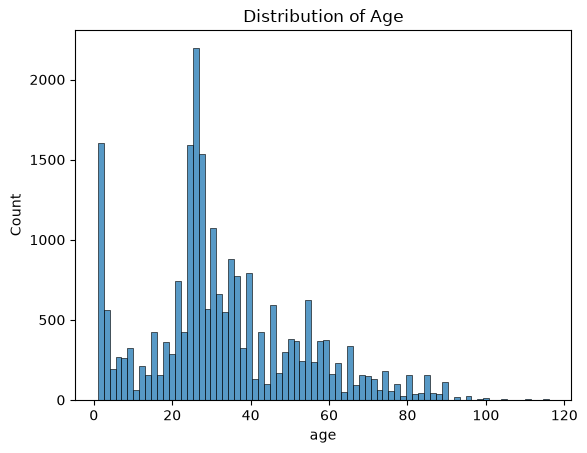

In [49]:
sns.histplot(data.age).set(title="Distribution of Age")

In [50]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23708 entries, 0 to 23707
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   image   23708 non-null  str    
 1   age     23708 non-null  float32
 2   gender  23708 non-null  int32  
dtypes: float32(1), int32(1), str(1)
memory usage: 1.2 MB


In [51]:
data.describe()

,age,gender
count,23708.000000,23708.000000
mean,33.303486,0.477349
std,19.886112,0.499497
min,1.000000,0.000000
25%,23.000000,0.000000
50%,29.000000,0.000000
75%,45.000000,1.000000
max,116.000000,1.000000


<Axes: title={'center': 'Gender Distribution'}, xlabel='gender'>

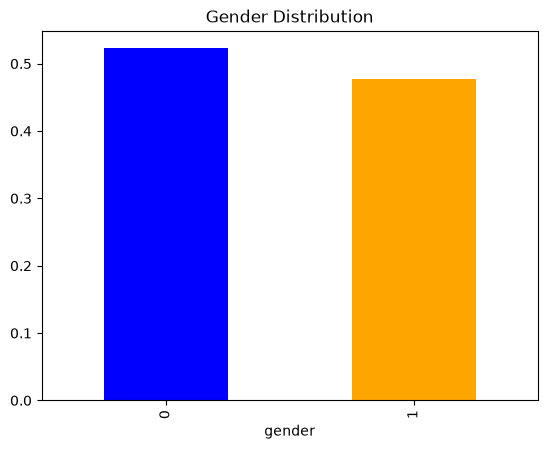

In [52]:
data['gender'].value_counts(normalize=True).plot(kind='bar', title='Gender Distribution', color=['blue', 'orange'])

Balanced Data

Outliers are needed to predict the age, gender of old people, babies as well.

In [53]:
train, test = train_test_split(data, test_size=0.2, random_state=42)

In [54]:
import cv2
x_train = []
for file in train.image:
    img = cv2.imread("C:/Users/Krishna Desaboina/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/utkface_aligned_cropped/UTKFace/" + file,cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
    img = cv2.resize(img,(224, 224),interpolation=cv2.INTER_LANCZOS4)
    x_train.append(img)

x_train_tl = np.array(x_train)
print(x_train_tl.shape)

(18966, 224, 224, 3)


ViT can take a colour image so proceeding with colour image

In [55]:
x_train = []
for file in train.image:
    img = cv2.imread("C:/Users/Krishna Desaboina/.cache/kagglehub/datasets/jangedoo/utkface-new/versions/1/utkface_aligned_cropped/UTKFace/" + file,cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img,(224, 224),interpolation=cv2.INTER_LANCZOS4)
    x_train.append(img)

x_train_sc = np.array(x_train)
print(x_train_sc.shape)

(18966, 224, 224)


In [56]:
x_train = x_train_tl/255
y_gender = np.array(train.gender)
y_age = np.array(train.age)

Just in case if the scartch model took to long for colour image then, will proceed with Gray Scale (Black and white)

Model From Scratch

In [26]:
input_size=x_train_tl.shape[1:]
inputs = Input((input_size))
X = Conv2D(64, (3, 3), activation='relu', kernel_initializer = glorot_uniform(seed=0))(inputs)
X = BatchNormalization(axis = 3)(X)
X = MaxPooling2D((3, 3))(X)

X = Conv2D(128, (3, 3), activation='relu')(X)
X = MaxPooling2D((2, 2), strides=(2, 2))(X)

X = Conv2D(256, (3,3), activation='relu')(X)
X = MaxPooling2D((2, 2))(X)

X = Flatten()(X)

dense_1 = Dense(256, activation='relu')(X)
dense_2 = Dense(256, activation='relu' )(X)
dense_3 = Dense(128, activation='relu' )(dense_2)
dropout_1 = Dropout(0.4)(dense_1)
dropout_2 = Dropout(0.4)(dense_3)
output_1 = Dense(1,activation='sigmoid', name='gender_output')(dropout_1)
output_2 = Dense(1, activation='relu', name='age_output')(dropout_2)

model = Model(inputs=[inputs], outputs=[output_1,output_2])

In [27]:
model.compile(
    optimizer='adam',
    loss={
        'gender_output': 'binary_crossentropy',
        'age_output': 'mse'  # or 'mae'
    },
    metrics={
        'gender_output': ['accuracy'],
        'age_output': ['mse']
    }
)

In [28]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 222, 222,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 74, 74,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 72, 72,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 36, 36,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 34, 34,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 17, 17,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 73984)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │ 18,940,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 18,940,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,284,674 (146.04 MB)

 Trainable params: 38,284,546 (146.04 MB)

 Non-trainable params: 128 (512.00 B)

In [29]:
early_stopping = EarlyStopping(patience=4, monitor='val_loss')
model_checkpoint = ModelCheckpoint(filepath='my_model.keras', save_best_only=True)
history = model.fit(x=x_train, y=[y_gender, y_age], batch_size = 10, epochs=20, validation_split= 0.1,callbacks = [early_stopping, model_checkpoint])

Epoch 1/20
1707/1707 ━━━━━━━━━━━━━━━━━━━━ 39487s 23s/step - age_output_loss: 277.6062 - age_output_mse: 277.6138 - gender_output_accuracy: 0.7655 - gender_output_loss: 0.5236 - loss: 278.1375 - val_age_output_loss: 183.3632 - val_age_output_mse: 183.5202 - val_gender_output_accuracy: 0.7939 - val_gender_output_loss: 0.4303 - val_loss: 183.9501
Epoch 2/20
1707/1707 ━━━━━━━━━━━━━━━━━━━━ 814s 477ms/step - age_output_loss: 157.6568 - age_output_mse: 157.6622 - gender_output_accuracy: 0.8346 - gender_output_loss: 0.3612 - loss: 158.0235 - val_age_output_loss: 308.6302 - val_age_output_mse: 308.9070 - val_gender_output_accuracy: 0.8419 - val_gender_output_loss: 0.3427 - val_loss: 309.2495
Epoch 3/20
1707/1707 ━━━━━━━━━━━━━━━━━━━━ 954s 559ms/step - age_output_loss: 138.1304 - age_output_mse: 138.1310 - gender_output_accuracy: 0.8562 - gender_output_loss: 0.3186 - loss: 138.4496 - val_age_output_loss: 122.6634 - val_age_output_mse: 122.8088 - val_gender_output_accuracy: 0.8593 - val_gender_out

Image of Dimensions : (224,224,3)  Colour Image

In [34]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 222, 222,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 74, 74,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 72, 72,    │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 36, 36,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 34, 34,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 17, 17,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 73984)     │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │ 18,940,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 18,940,160 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     32,896 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        257 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 114,853,768 (438.13 MB)

 Trainable params: 38,284,546 (146.04 MB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 76,569,094 (292.09 MB)

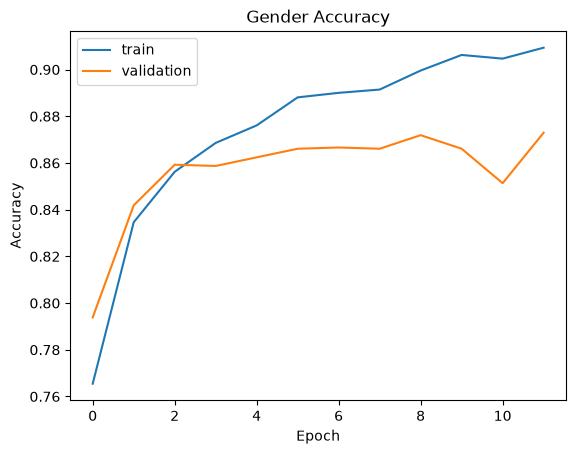

In [31]:
# Plotting gender accuracy 
plt.plot(history.history['gender_output_accuracy'])
plt.plot(history.history['val_gender_output_accuracy'])
plt.title('Gender Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

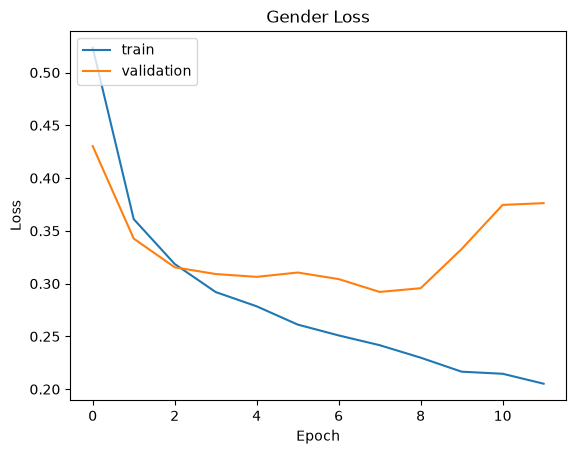

In [32]:
# Plotting gender loss 
plt.plot(history.history['gender_output_loss'])
plt.plot(history.history['val_gender_output_loss'])
plt.title('Gender Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

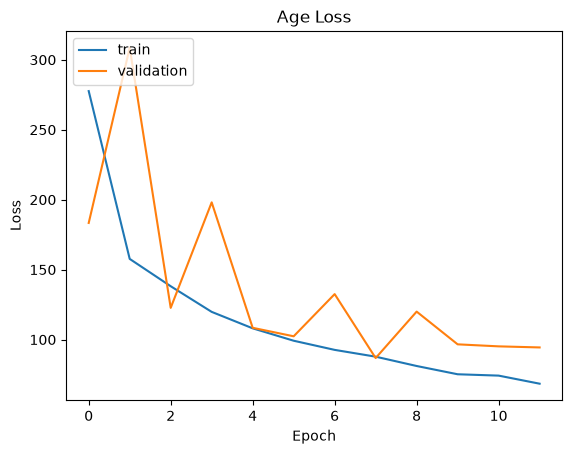

In [33]:
# Plotting age loss 
plt.plot(history.history['age_output_loss'])
plt.plot(history.history['val_age_output_loss'])
plt.title('Age Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Original: Gender =  Male  Age =  13.0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
Prediction: Gender =  Male  Age =  12


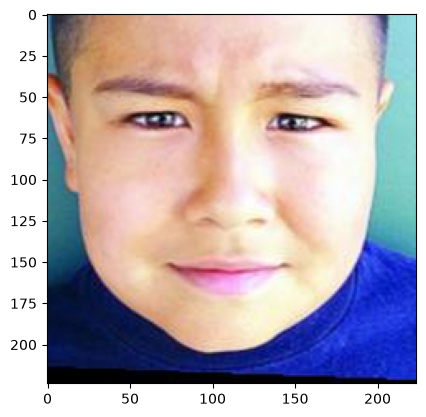

In [32]:
model = tf.keras.models.load_model("my_model.keras")
index=3
print("Original: Gender = ", gender_dict[y_gender[index]]," Age = ", y_age[index])

pred = model.predict(x_train[index].reshape(1, 224, 224, 3))
pred_gender = gender_dict[round(pred[0][0][0])] 
pred_age = round(pred[1][0][0])

print("Prediction: Gender = ", pred_gender," Age = ", pred_age)
plt.imshow(x_train[index].reshape(224, 224, 3))

Transfer Learning using ViT Transformer